<a href="https://colab.research.google.com/github/purnachand1186/Breast_Cancer_Analysis_ML/blob/main/1_Exploratary_Data_Analysis_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OVERVIEW**

In this application, I will explore Breast Cancer dataset from UC Irvine dataset ( https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). The same dataset is avaialbe in Python SK-Learn module. The goal of this project is to perform EDA on the data , perform analysis and predict the malignant patients with the information provided.

**Dataset Information**

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.  They describe characteristics of the cell nuclei present in the image. A few of the images can be found at http://www.cs.wisc.edu/~street/images/

Separating plane described above was obtained using Multisurface Method-Tree (MSM-T) [K. P. Bennett, "Decision Tree Construction Via Linear Programming." Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992], a classification method which uses linear programming to construct a decision tree.  Relevant features were selected using an exhaustive search in the space of 1-4 features and 1-3 separating planes.

The actual linear program used to obtain the separating plane in the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server:
ftp ftp.cs.wisc.edu
cd math-prog/cpo-dataset/machine-learn/WDBC/



**Attribute Information:**

1) ID number

2) Diagnosis (M (0) = malignant, B (1) = benign)
3-32)


Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)



Class distribution: 357 benign, 212 malignant

### Load Required Python Libraries

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import time

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#load data from sklearn
from sklearn.datasets import load_breast_cancer


from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder,LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, average_precision_score,make_scorer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


import warnings
warnings.filterwarnings('ignore')

In [89]:
import logging
logging.getLogger().setLevel(logging.CRITICAL)

### Data Understanding

Load the data and provide basic data analysis using Pandas.

In [90]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
cancer_data= pd.DataFrame(X,columns=cancer.feature_names)
cancer_df = cancer_data.copy()
cancer_df['target']=y
cancer_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [91]:
# no of rows and columns in data
print(f'Rows : {cancer_df.shape[0]} , Features:  {cancer_df.shape[1]}')

Rows : 569 , Features:  31


In [92]:
#describe data fram
cancer_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [93]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [94]:
#find the percentage of values in target column
tar_unique_vals = cancer_df['target'].value_counts(normalize=True)
tar_unique_vals

,proportion
target,
1,0.627417
0,0.372583


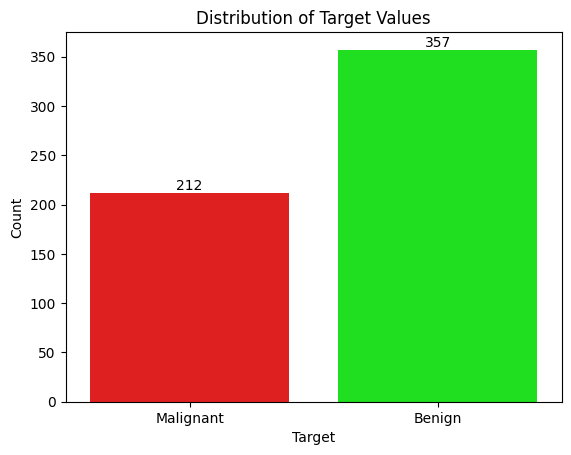

In [95]:
# draw distribution of target values benign, malignant

ax = sns.countplot(x='target', data=cancer_df,palette=["#FF0000", "#00FF00"])
for con in ax.containers:
    ax.bar_label(con)
plt.title('Distribution of Target Values')
plt.xlabel('Target')
plt.ylabel('Count')
ax.set_xticklabels(['Malignant', 'Benign'])
plt.savefig('images/target_distribution.jpeg')
plt.show()

**From the above diagram, there are 212 number of Malignant cases, i.e. patients with breast cancer and 357 cases which do not have breast cancer, data is somewhat is unblanced, but good enough for our analysis**

In [96]:
#create a data frame with missing values and percentage of missing values for each column
def missing_df(df):
  total_missing_value = df.isnull().sum()
  percent_missing_value = round(total_missing_value*100/len(df),2)
  missing_valus_df = pd.DataFrame({'count': total_missing_value, 'percentage': percent_missing_value})
  return missing_valus_df

In [97]:
#show missing data in the datafram
missing_data = missing_df(cancer_df)
missing_data[missing_data['count']>0]

,count,percentage


#### No missing data found in the data

In [98]:
# list of categorical columns
cat_cols = cancer_df.select_dtypes(include='object').columns.tolist()
cat_cols

[]

In [99]:
# list of numerical columns
int_cols = cancer_df.select_dtypes(exclude='object').columns.tolist()
int_cols

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

In [100]:
# data after group by target value
cancer_df.groupby('target').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


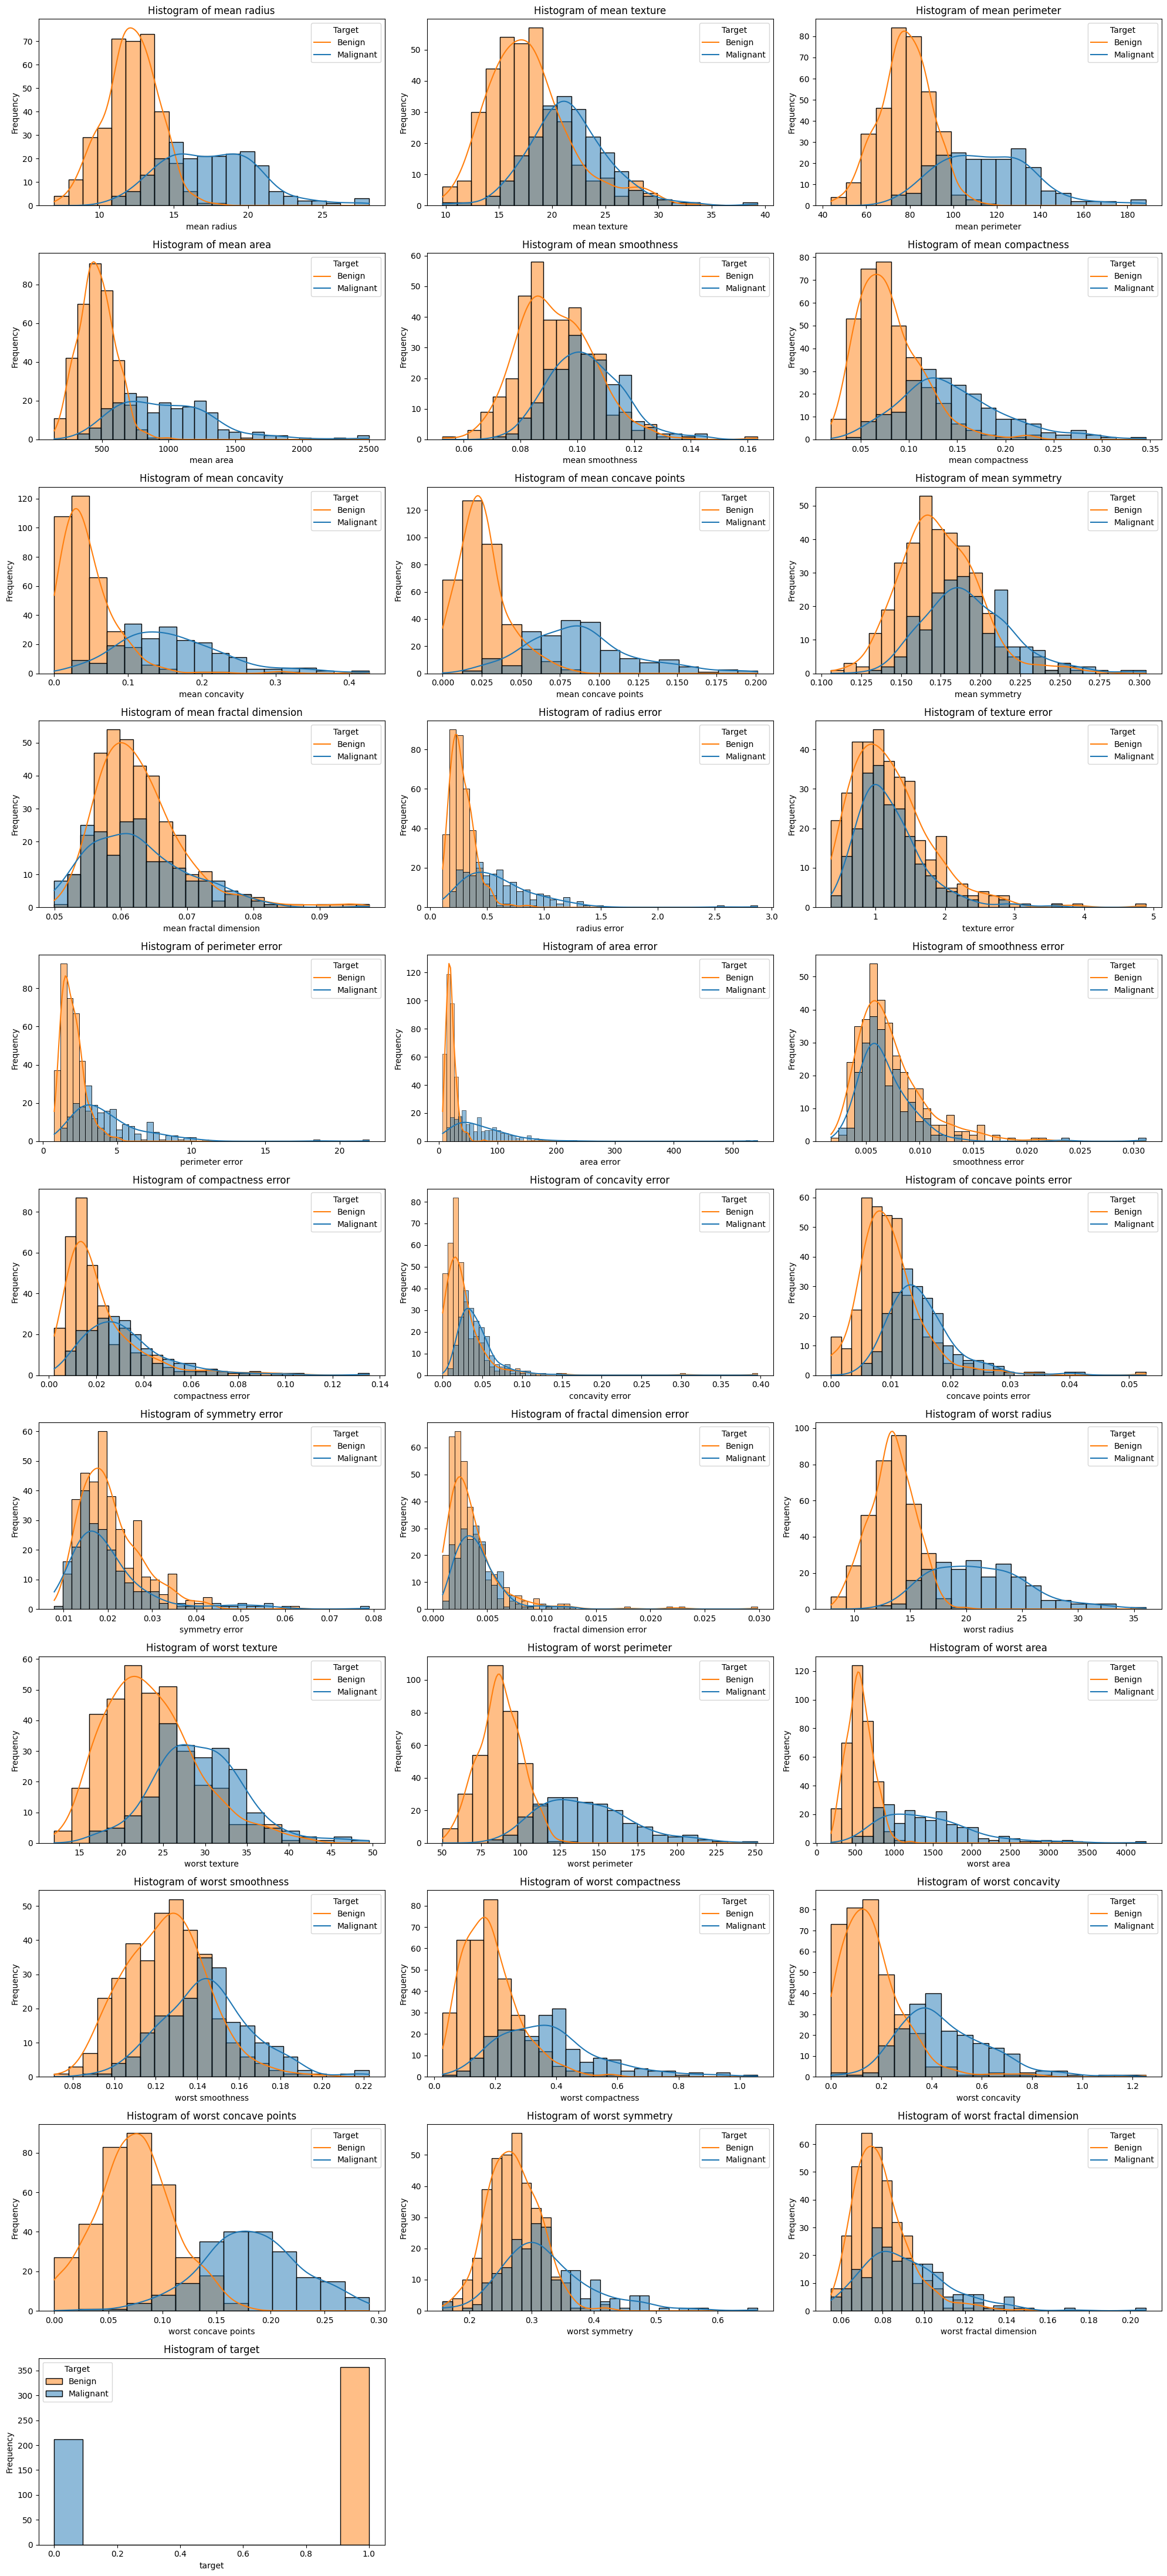

In [101]:
#draw histograms for each feature in subplots

num_features = len(int_cols)
num_cols = 3  # Number of columns for subplots
num_rows = (num_features + num_cols - 1) // num_cols  # Calculate number of rows needed
# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 4 * num_rows))

# Plot histograms for each feature
for i, feature in enumerate(cancer_df.columns):
        row = i // num_cols
        col = i % num_cols
        sns.histplot(data = cancer_df, x =feature, ax=axes[row,col], kde=True, hue='target')
        axes[row, col].set_title(f'Histogram of {feature}')
        axes[row, col].set_xlabel(feature)
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].legend(title='Target', labels=['Benign', 'Malignant'])

# Remove any empty subplots
for i in range(num_features, num_rows * num_cols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.savefig('images/feature_distribution_histograms.jpeg')
plt.show()


##From the above diagrams, There seems to be outliers exists for columns 'radious error', 'perimter error', 'area error', 'symmetry error' & 'fractal diemention error'

In [102]:
# remove outliers from the columns
def remove_outliers(df, column):
    factor =1.5
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - factor * IQR
    upper_bound = Q3 + factor * IQR
    df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

#### Data after removing outliers for columns 'radius error'

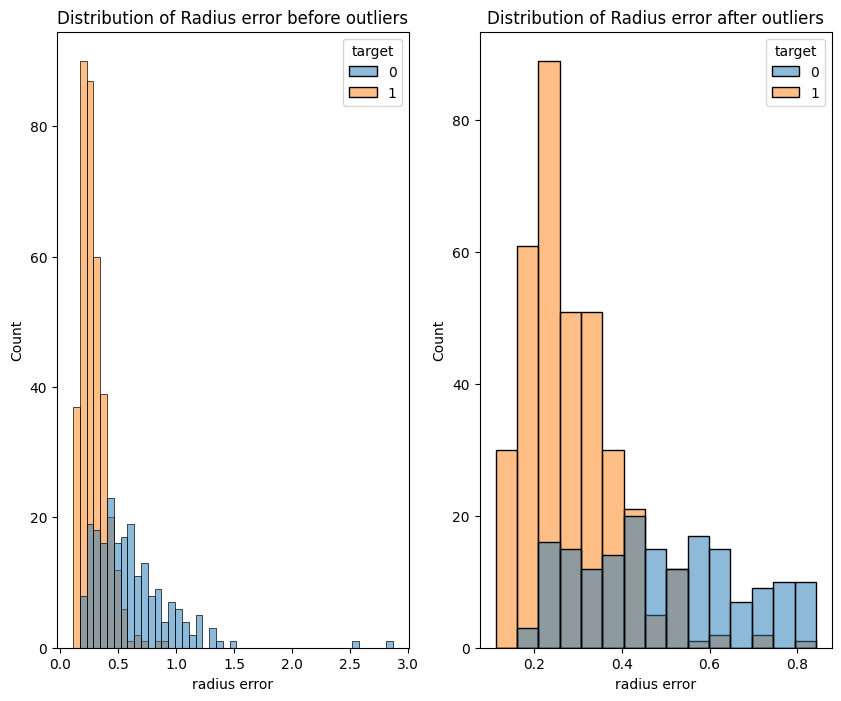

In [103]:
#before & after deleting outliers for 'radious error'
fig, ax= plt.subplots(1,2,figsize=(10,8))
fig = sns.histplot(data = cancer_df,x='radius error', ax= ax[0], hue='target').set(title='Distribution of Radius error before outliers')
cancer_df = remove_outliers(cancer_df,'radius error')
fig = sns.histplot(data = cancer_df,x='radius error', ax=ax[1], hue='target').set(title='Distribution of Radius error after outliers')
plt.savefig('images/before_after_outliers_radios_error.jpeg')
plt.show()

#### Data after removing outliers for columns 'perimeter error'

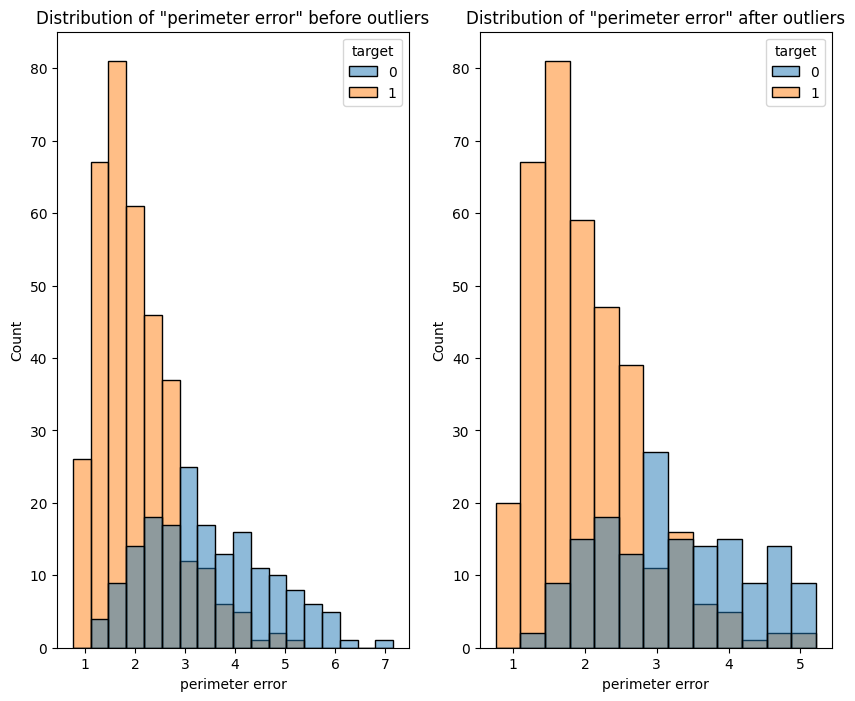

In [104]:
#before & after deleting outliers for 'perimeter error'
fig, ax= plt.subplots(1,2,figsize=(10,8))
fig = sns.histplot(data=cancer_df,x='perimeter error', ax= ax[0], hue='target').set(title='Distribution of "perimeter error" before outliers')
cancer_df = remove_outliers(cancer_df,'perimeter error')
fig = sns.histplot(data=cancer_df,x='perimeter error', ax=ax[1], hue='target').set(title='Distribution of "perimeter error" after outliers')
plt.savefig('images/before_after_outliers_perimeter_error.jpeg')
plt.show()

#### Data after removing outliers for columns 'area error'

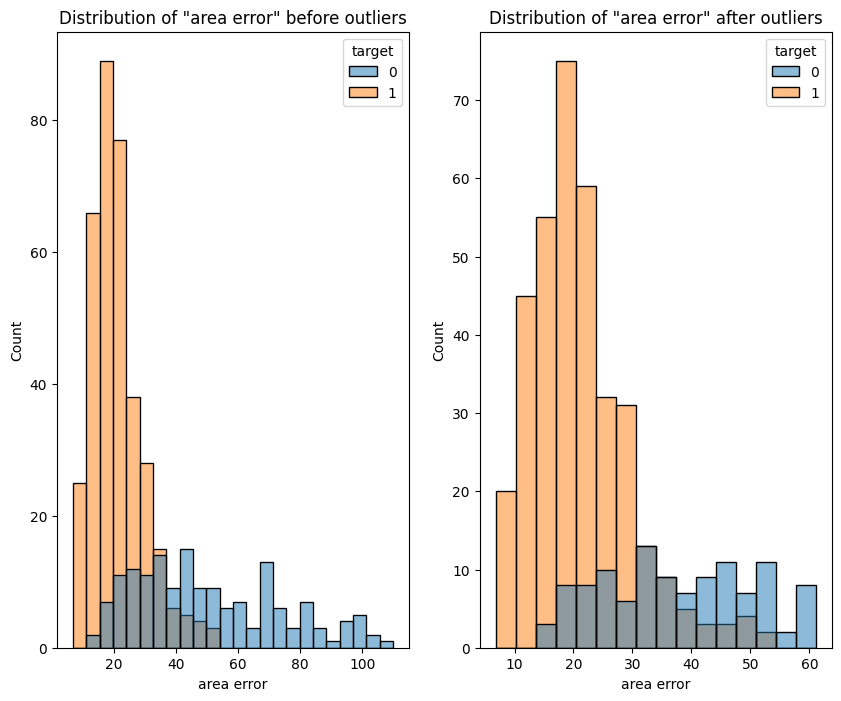

In [105]:
#before & after deleting outliers for 'area error'
fig, ax= plt.subplots(1,2,figsize=(10,8))
fig = sns.histplot(data=cancer_df,x='area error', ax= ax[0],  hue='target').set(title='Distribution of "area error" before outliers')
cancer_df = remove_outliers(cancer_df,'area error')
fig = sns.histplot(data=cancer_df, x='area error', ax=ax[1], hue='target').set(title='Distribution of "area error" after outliers')
plt.savefig('images/before_after_outliers_ares_error.jpeg')
plt.show()

**Lets find out the correlations among the features**

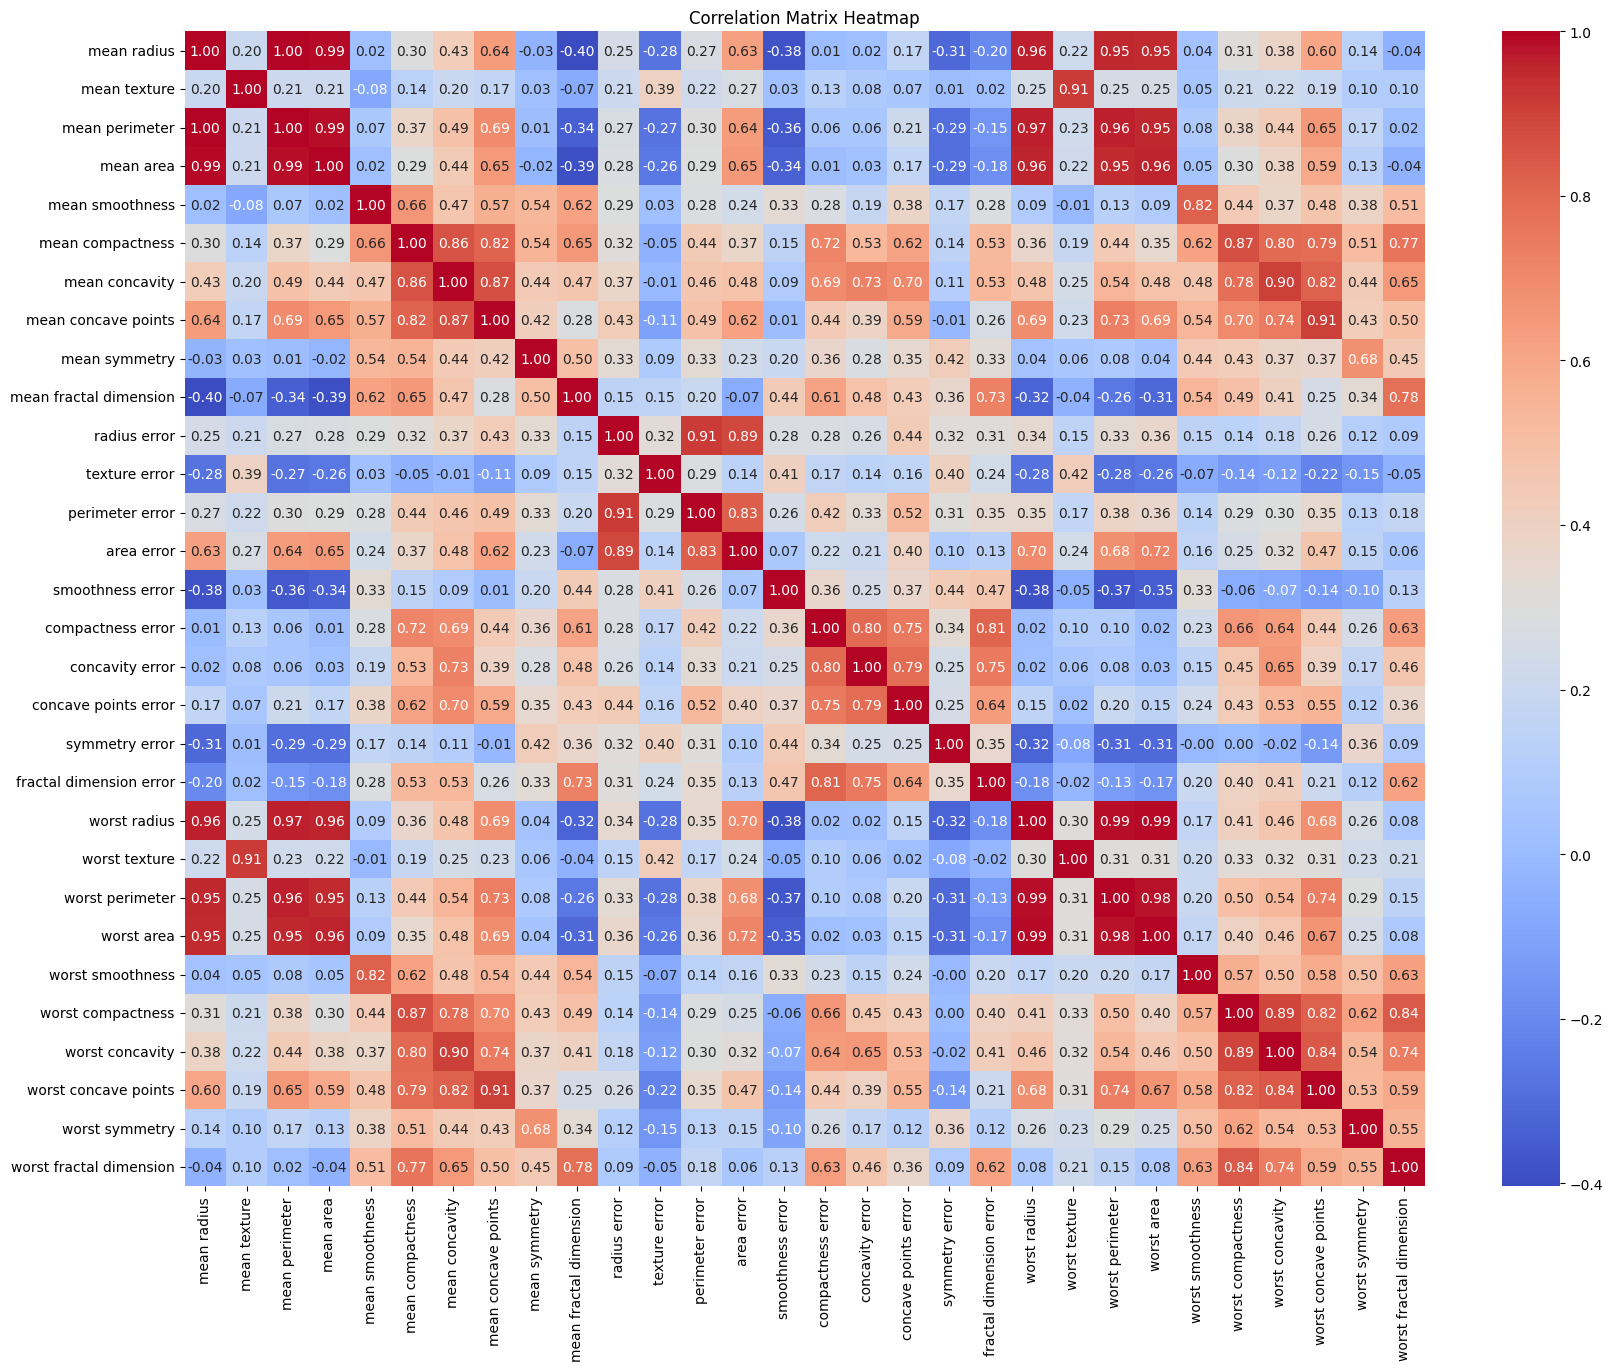

In [106]:
# Correlation heat map after dropping target column
plt.figure(figsize=(20,15))
sns.heatmap(cancer_df.drop(columns='target').corr(), cmap='coolwarm', fmt=".2f", annot=True)
plt.title('Correlation Matrix Heatmap')
plt.savefig('images/heatmap.jpeg')
plt.show()

**Observations**

*Strong Positive Correlations*:
  

1.   'mean perimter' & 'mean radious' features has a string positive correlation (Same case with 'worst perimeter' & 'worst radious')
2.   'mean radious' & 'mean area' features also has a string positive correlation (Same case with 'worst radious' & 'worst area')
3.  'mean area' & 'mean radious'  features has a string positive correlation (Same case with 'worst area' & 'worst radious')
4. 'mean compactness' & 'mean concavity' features has a string positive correlation



*Medium Positive Correlations*:

1.  'mean concave point' & 'mean radious' features has a medium positive correlation
2. 'mean concave point' & 'mean Compactness' features has a medium positive correlation
3. 'mean texture' & 'mean radious' features has a medium positive correlation
4.  'mean texture' & 'mean area' features also has a medium positive




#### Draw the joint plots for string postive correlations

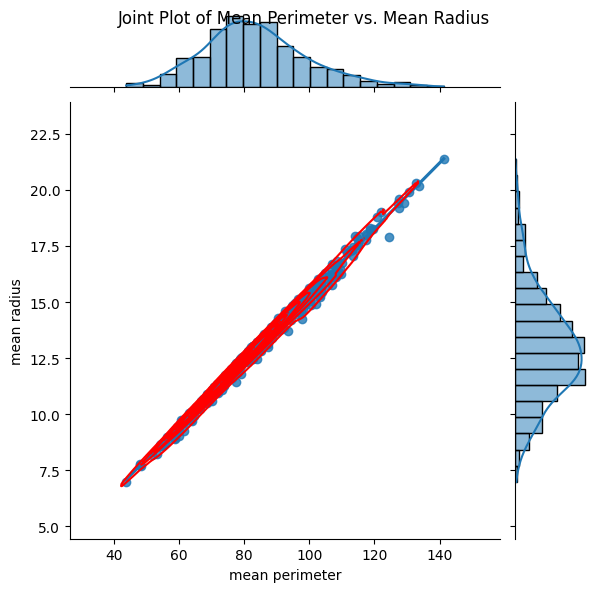

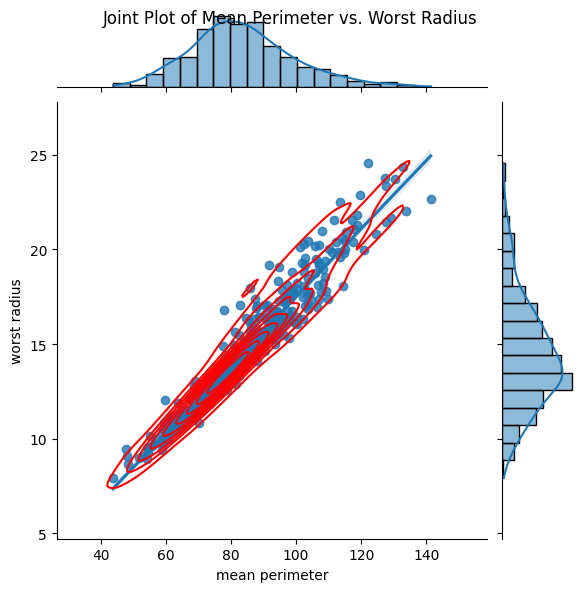

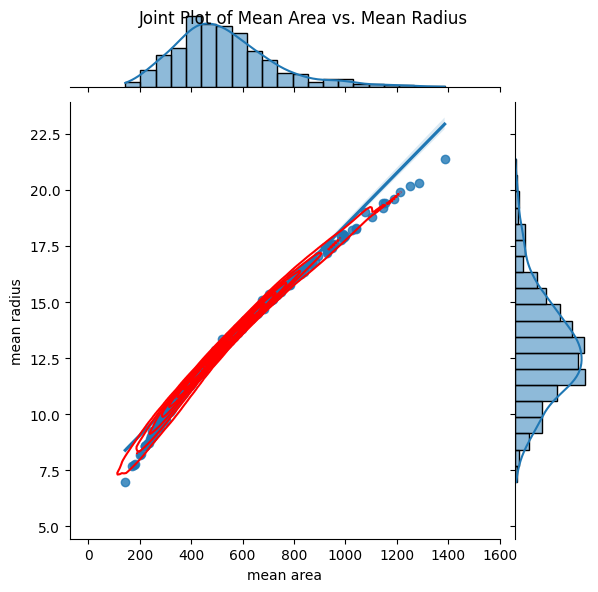

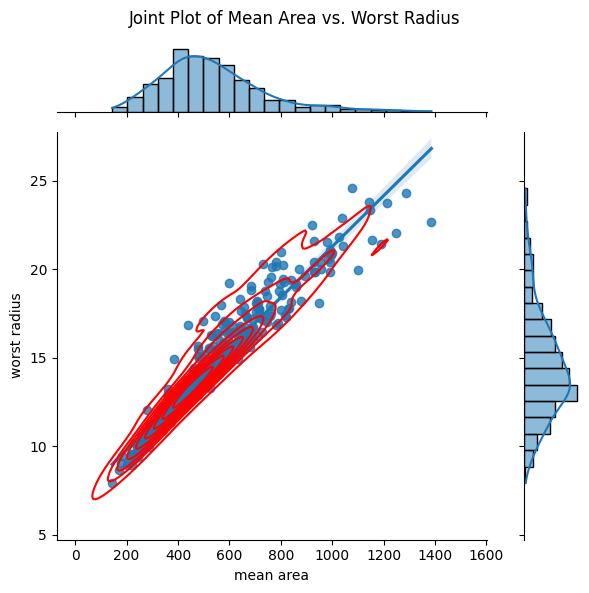

In [107]:
# Draw Joint plots among the string correlated features
p = sns.jointplot(data=cancer_df, x='mean perimeter', y='mean radius', kind='reg')
p.plot_joint(sns.kdeplot, color='red')
p.fig.suptitle('Joint Plot of Mean Perimeter vs. Mean Radius')
q = sns.jointplot(data=cancer_df, x='mean perimeter', y='worst radius', kind='reg')
q.plot_joint(sns.kdeplot, color='red')
q.fig.suptitle('Joint Plot of Mean Perimeter vs. Worst Radius')
r= sns.jointplot(data=cancer_df, x='mean area', y='mean radius', kind='reg')
r.plot_joint(sns.kdeplot, color='red')
r.fig.suptitle('Joint Plot of Mean Area vs. Mean Radius')
s = sns.jointplot(data=cancer_df, x='mean area', y='worst radius', kind='reg')
s.plot_joint(sns.kdeplot, color='red')
s.fig.suptitle('Joint Plot of Mean Area vs. Worst Radius')
plt.tight_layout()
plt.show()

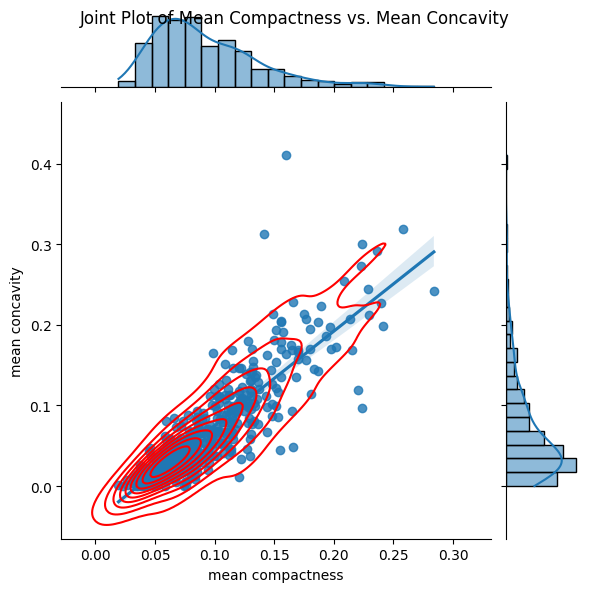

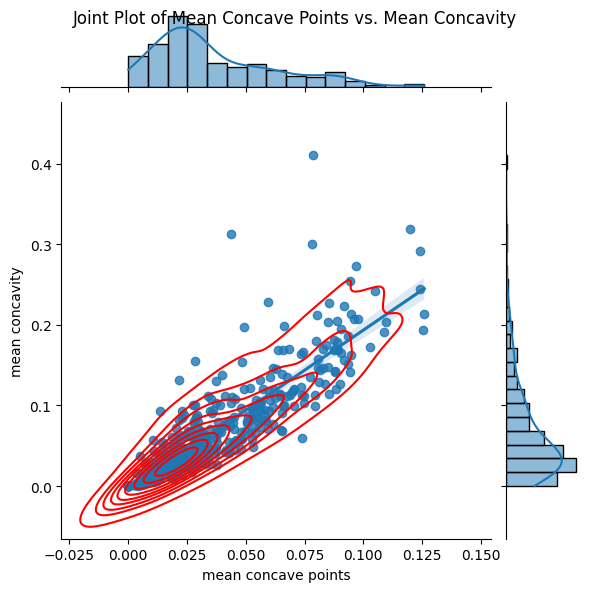

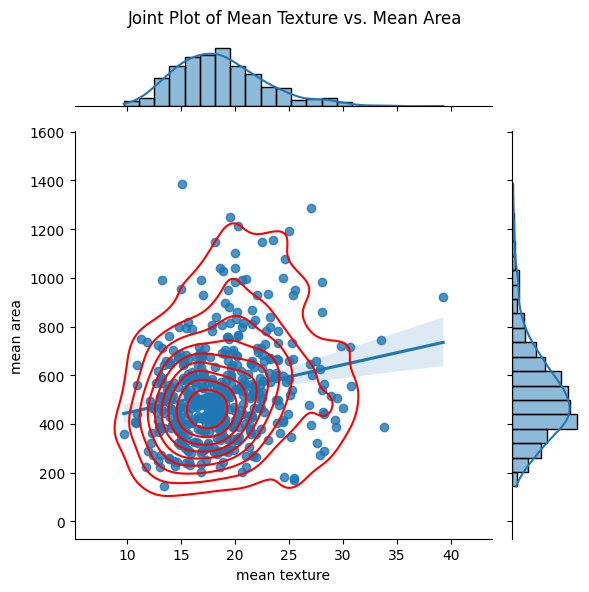

In [108]:
# draw correlation among compactness_mean,concavity_mean, concave points_mean
t = sns.jointplot(data=cancer_df, x='mean compactness', y='mean concavity', kind='reg')
t.plot_joint(sns.kdeplot, color='red')
t.fig.suptitle('Joint Plot of Mean Compactness vs. Mean Concavity')
u = sns.jointplot(data=cancer_df, x='mean concave points', y='mean concavity', kind='reg')
u.plot_joint(sns.kdeplot, color='red')
u.fig.suptitle('Joint Plot of Mean Concave Points vs. Mean Concavity')
v = sns.jointplot(data=cancer_df, x='mean texture', y='mean area', kind='reg')
v.plot_joint(sns.kdeplot, color='red')
v.fig.suptitle('Joint Plot of Mean Texture vs. Mean Area')
plt.tight_layout()
plt.show()

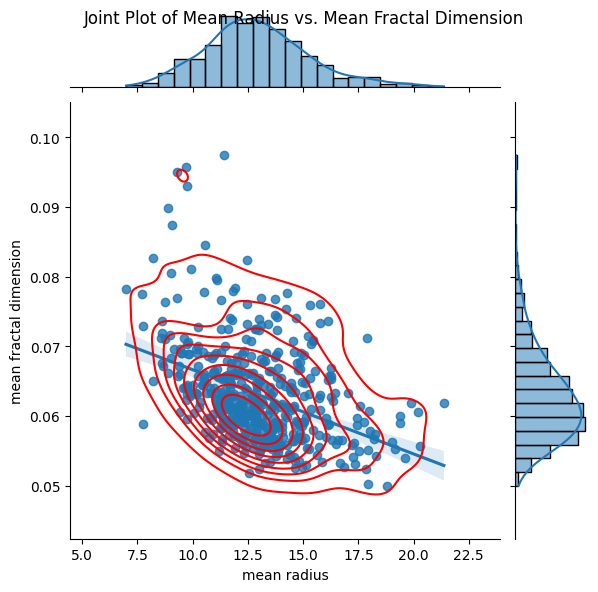

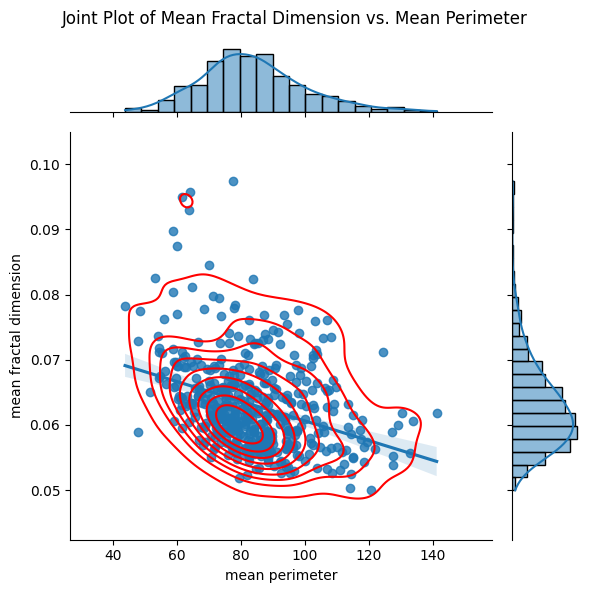

In [23]:
# draw negative correlation between radius_mean, fractual_diemension_mean, perimeter_mean
a = sns.jointplot(data=cancer_df, x='mean radius', y='mean fractal dimension', kind='reg')
a.plot_joint(sns.kdeplot, color='red')
a.fig.suptitle('Joint Plot of Mean Radius vs. Mean Fractal Dimension')
b = sns.jointplot(data=cancer_df, x='mean perimeter', y='mean fractal dimension', kind='reg')
b.plot_joint(sns.kdeplot, color='red')
b.fig.suptitle('Joint Plot of Mean Fractal Dimension vs. Mean Perimeter')
plt.tight_layout()
plt.show()

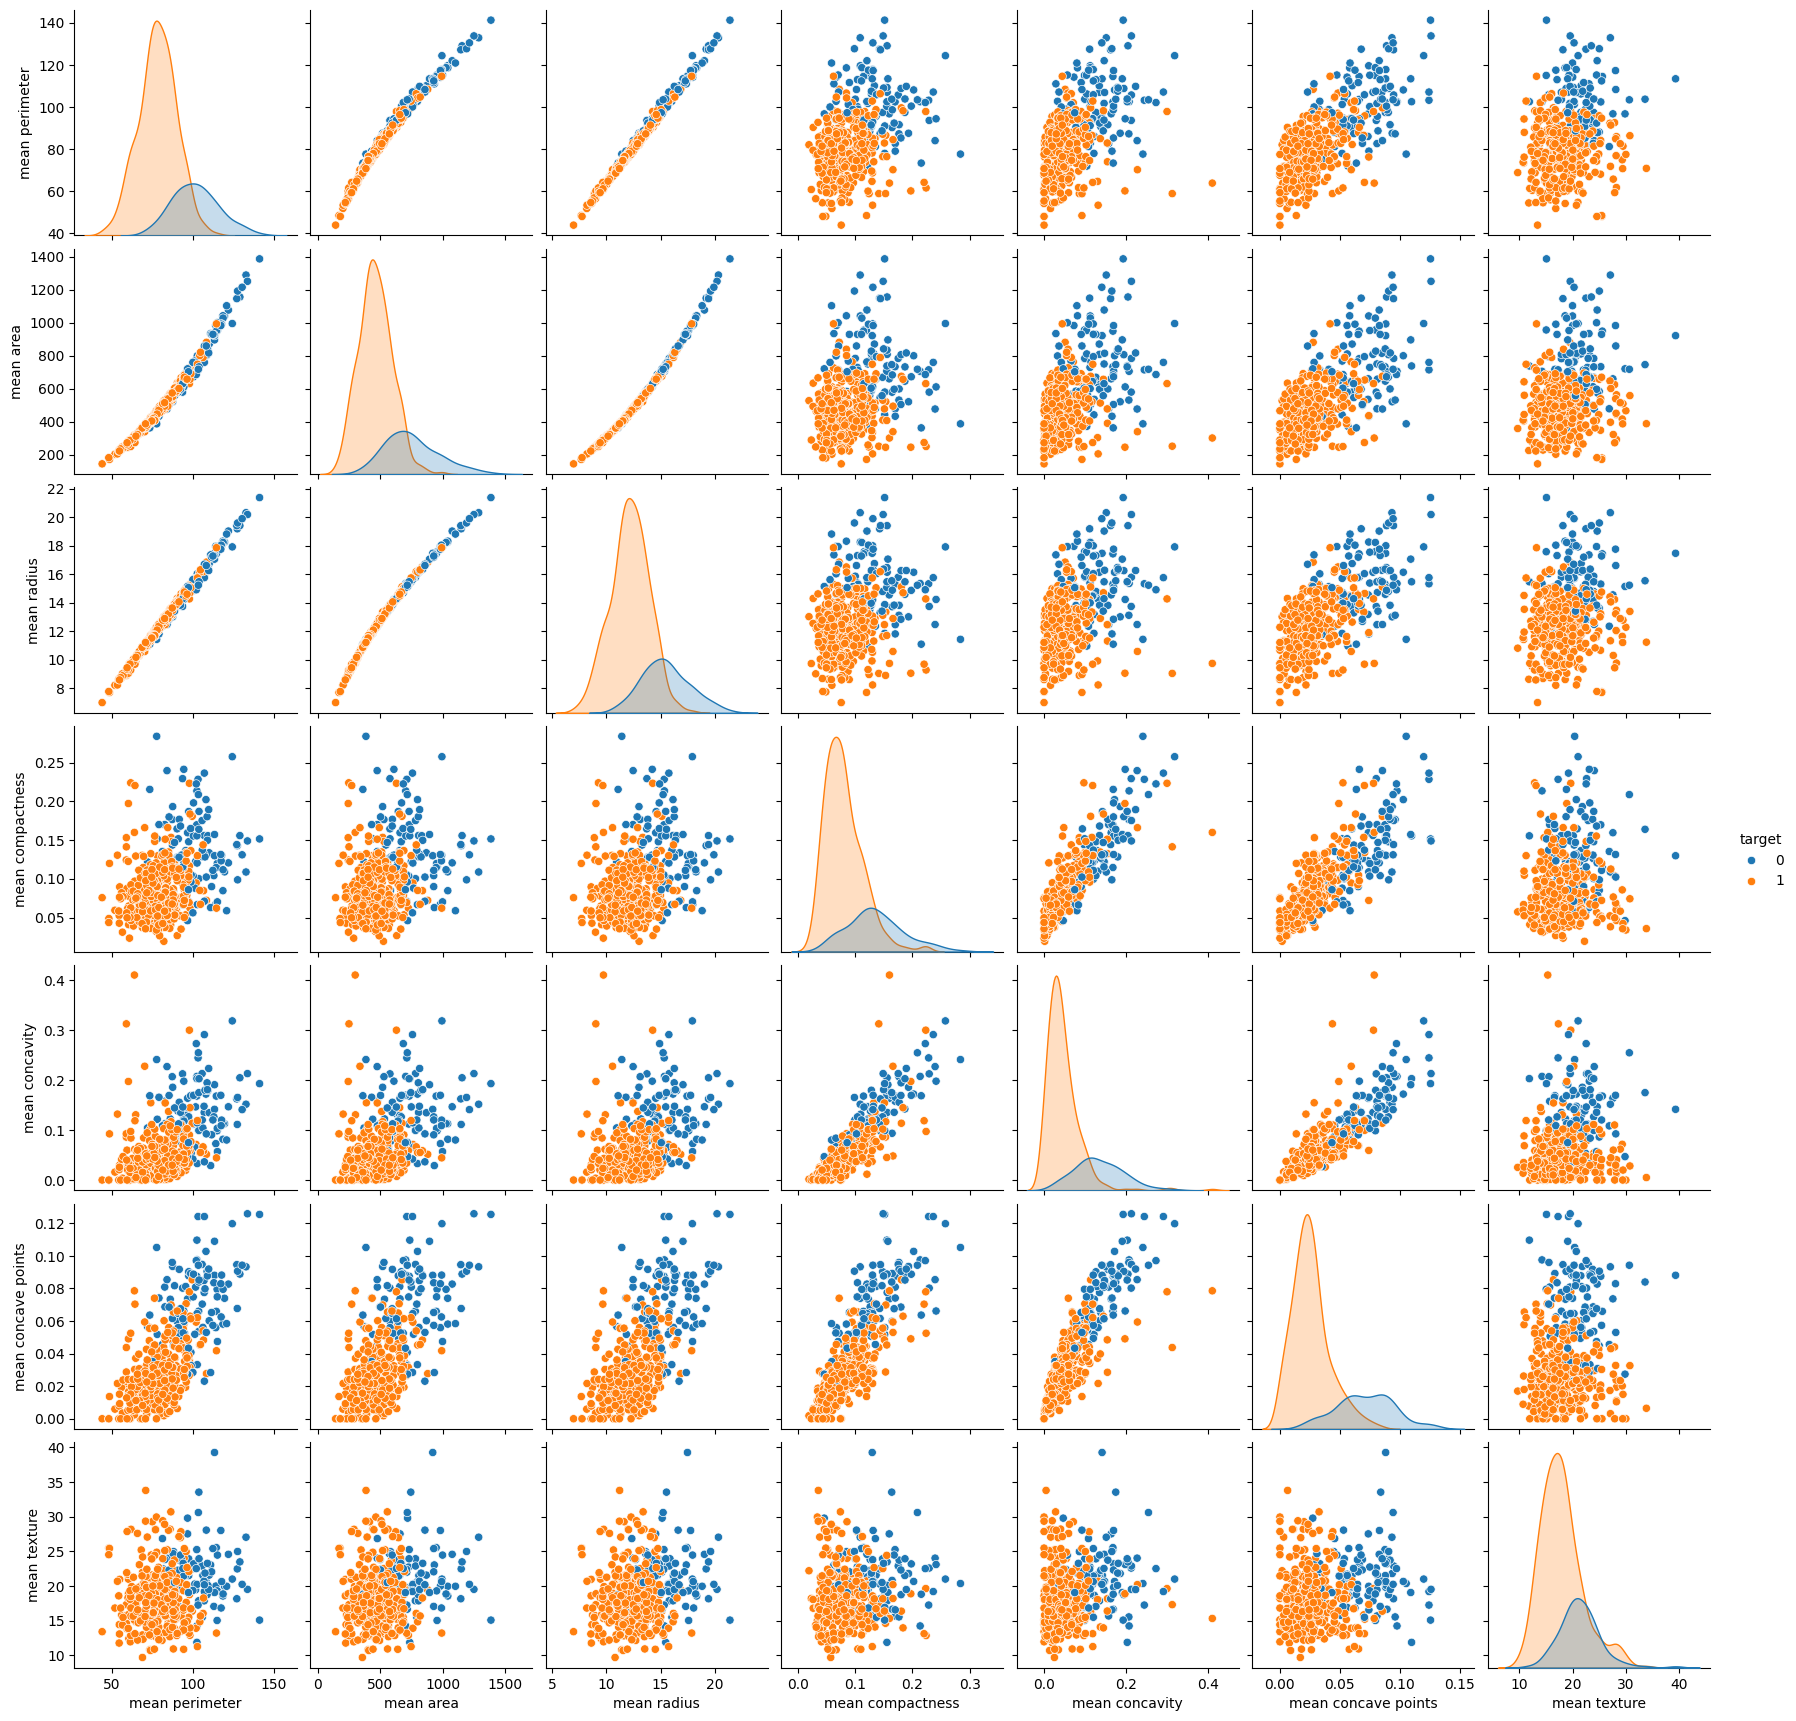

In [24]:
# draw pair plot for string correlated columns

columns = ['mean perimeter','mean area','mean radius','mean compactness', 'mean concavity','mean concave points','mean texture']
sns.pairplot(cancer_df, vars=columns, hue='target', diag_kind='kde')
plt.savefig('images/pairplot_columns.jpeg')
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [109]:
#Raw data before standardization
print("Original Data:")
print(cancer_df.head())

Original Data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
3        11.42         20.38           77.58      386.1          0.14250   
5        12.45         15.70           82.57      477.1          0.12780   
6        18.25         19.98          119.60     1040.0          0.09463   
7        13.71         20.83           90.20      577.9          0.11890   
8        13.00         21.82           87.50      519.8          0.12730   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
3            0.2839         0.24140              0.10520         0.2597   
5            0.1700         0.15780              0.08089         0.2087   
6            0.1090         0.11270              0.07400         0.1794   
7            0.1645         0.09366              0.05985         0.2196   
8            0.1932         0.18590              0.09353         0.2350   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \

#### Normalize the data using Standard Scaler and Normialization

In [110]:
#Peforming Scaling
scaler = StandardScaler()
scaled_data_df = scaler.fit_transform(cancer_df.drop(columns='target'))

# Add scaled data to the dataframe
cencer_scaled_df = pd.DataFrame(scaled_data_df, columns=cancer_data.columns)

In [111]:
# Display the first few rows of the transformed dataset
print("\n Scaled Data:")
print(cencer_scaled_df.head())


 Scaled Data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -0.644248      0.389059       -0.381986  -0.730793         3.348055   
1    -0.206262     -0.717450       -0.069596  -0.274191         2.310398   
2     2.260065      0.294486        2.248595   2.550221        -0.031037   
3     0.329526      0.495455        0.408065   0.231584         1.682157   
4     0.027614      0.729524        0.239037  -0.059939         2.275104   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          4.284467        2.877049             2.601353       3.127264   
1          1.725781        1.497876             1.681209       1.168857   
2          0.355457        0.753849             1.420419       0.043733   
3          1.602227        0.439741             0.884835       1.587419   
4          2.246953        1.961450             2.159639       2.178781   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter 

In [112]:
#perrform normalization
normalizer = MinMaxScaler()
normalized_data = normalizer.fit_transform(cancer_data)

# Add normalized data to the dataframe
cancer_normalized_df = pd.DataFrame(normalized_data, columns=cancer_data.columns)
cancer_normalized_df['target'] = cancer.target


cancer_normalized_df = remove_outliers(cancer_normalized_df,'radius error')
cancer_normalized_df = remove_outliers(cancer_normalized_df,'perimeter error')
cancer_normalized_df = remove_outliers(cancer_normalized_df,'area error')

# # Calculate IQR for each feature
# Q1 = cancer_normalized_df.quantile(0.25)
# Q3 = cancer_normalized_df.quantile(0.75)
# IQR = Q3 - Q1

# # Filter out the outliers using IQR
# filtered_df = cancer_normalized_df[~((cancer_normalized_df < (Q1 - 1.5 * IQR)) | (cancer_normalized_df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("\n Normalized Data:")
print(cancer_normalized_df.head())


 Normalized Data:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
3     0.210090      0.360839        0.233501   0.102906         0.811321   
5     0.258839      0.202570        0.267984   0.141506         0.678613   
6     0.533343      0.347311        0.523875   0.380276         0.379164   
7     0.318472      0.376057        0.320710   0.184263         0.598267   
8     0.284869      0.409537        0.302052   0.159618         0.674099   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
3          0.811361        0.565604             0.522863       0.776263   
5          0.461996        0.369728             0.402038       0.518687   
6          0.274891        0.264058             0.367793       0.370707   
7          0.445126        0.219447             0.297465       0.573737   
8          0.533157        0.435567             0.464861       0.651515   

   mean fractal dimension  ...  worst texture  worst perimeter  worst are

In [113]:
cancer_normalized_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 468 entries, 3 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              468 non-null    float64
 1   mean texture             468 non-null    float64
 2   mean perimeter           468 non-null    float64
 3   mean area                468 non-null    float64
 4   mean smoothness          468 non-null    float64
 5   mean compactness         468 non-null    float64
 6   mean concavity           468 non-null    float64
 7   mean concave points      468 non-null    float64
 8   mean symmetry            468 non-null    float64
 9   mean fractal dimension   468 non-null    float64
 10  radius error             468 non-null    float64
 11  texture error            468 non-null    float64
 12  perimeter error          468 non-null    float64
 13  area error               468 non-null    float64
 14  smoothness error         468 no

### Base Model

With (almost?) final dataset in hand, it is now time to build a bsci model

In [115]:
# Perform Base Model on the above normalized data
X = cancer_normalized_df.drop(columns='target')
y = cancer_normalized_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the logistic regression model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the normalized logistic regression model: {accuracy:.2f}")

Accuracy of the normalized logistic regression model: 0.97


The number of positive instances correctly predicted as positive (TP): 77
The number of negative instances correctly predicted as negative (TN): 14
The number of positive instances incorrectly predicted as negative (FN): 0
The number of negative instances incorrectly predicted as positive (FP): 3


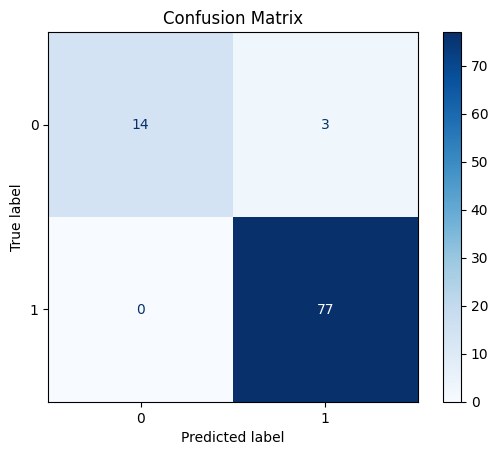

In [118]:
#generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
# Extract TP, TN, FP, FN values from the confusion matrix
TN, FP, FN, TP = conf_matrix.ravel()
print(f"The number of positive instances correctly predicted as positive (TP): {TP}")
print(f"The number of negative instances correctly predicted as negative (TN): {TN}")
print(f"The number of positive instances incorrectly predicted as negative (FN): {FN}")
print(f"The number of negative instances incorrectly predicted as positive (FP): {FP}")
# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('images/confusion_matrix.jpeg')
plt.show()

In [119]:
# calculate  precision, recall, F1 score values
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


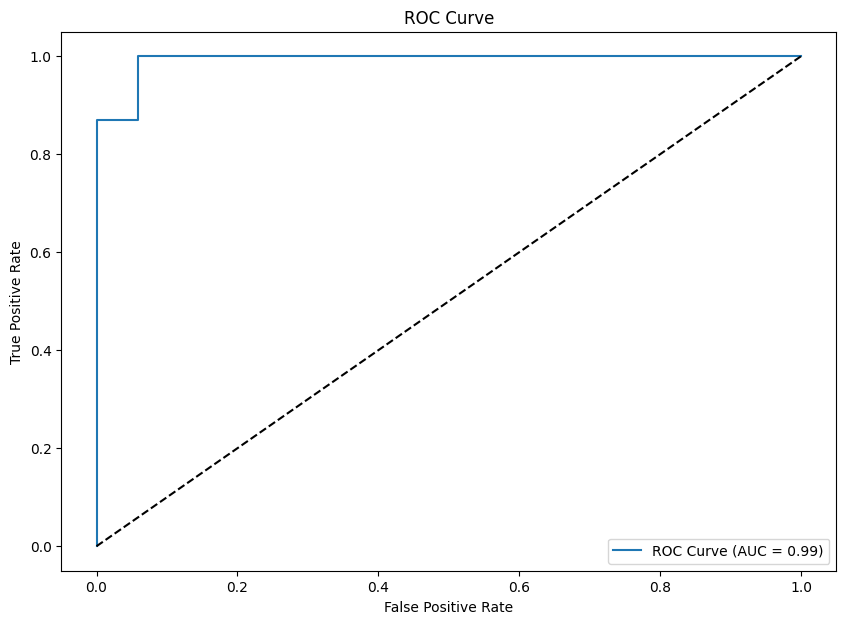

In [120]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_proba)
# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.savefig('images/ROC_Curve_base_model.jpeg')
plt.show()

###Feature Importance

Using Random Forest Decision tree, lets try to identify to important features for this dataset

In [126]:
#use random regressor to find feature importance
from sklearn.ensemble import RandomForestRegressor

rdModel = RandomForestRegressor()
rdModel.fit(X_train, y_train)

importance = rdModel.feature_importances_
importance_df = pd.DataFrame(importance, index=cancer_normalized_df.drop(columns='target').columns, columns=["Importance"])
importance_df.sort_values(by='Importance', ascending=False)

,Importance
worst concave points,0.305483
worst perimeter,0.221738
worst area,0.101617
worst radius,0.078728
mean concave points,0.061177
worst texture,0.053004
worst smoothness,0.032227
mean texture,0.019299
mean concavity,0.017076
area error,0.015801


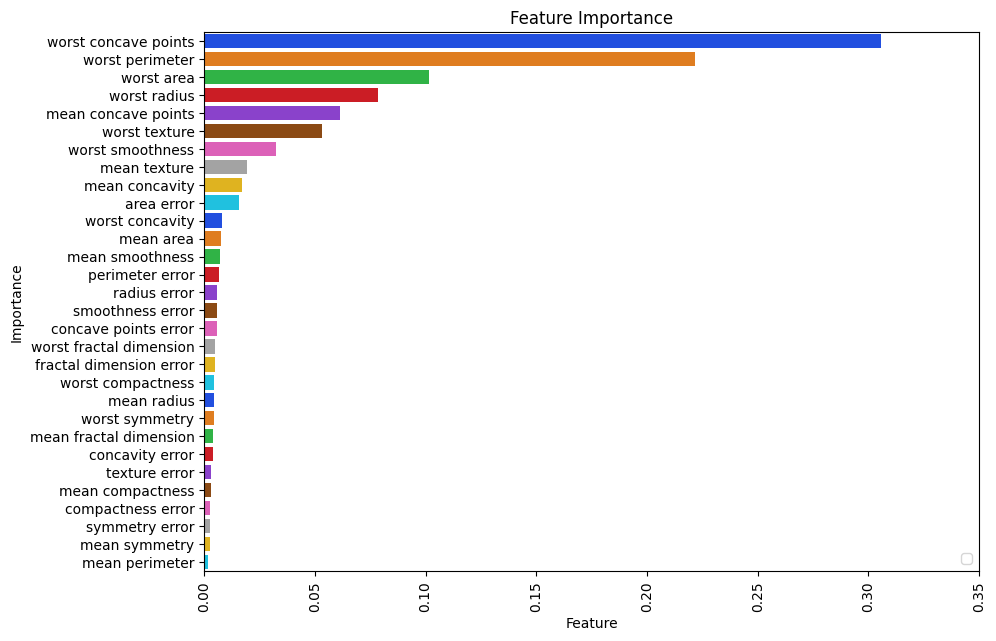

In [127]:
#draw plot of importance using sns
df_sorted = importance_df.sort_values(by='Importance', ascending=False)
fig,ax = plt.subplots(figsize=(10,7))
fig = sns.barplot(y=df_sorted.index, x=df_sorted.Importance, data =df_sorted,  ax=ax, palette='bright', hue=importance_df.index, legend= False)
ax.xaxis.set_ticks(ax.get_xticks()[::1])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.title('Feature Importance')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.legend(loc='lower right')
plt.savefig('images/feature_importance.jpeg')
plt.show()

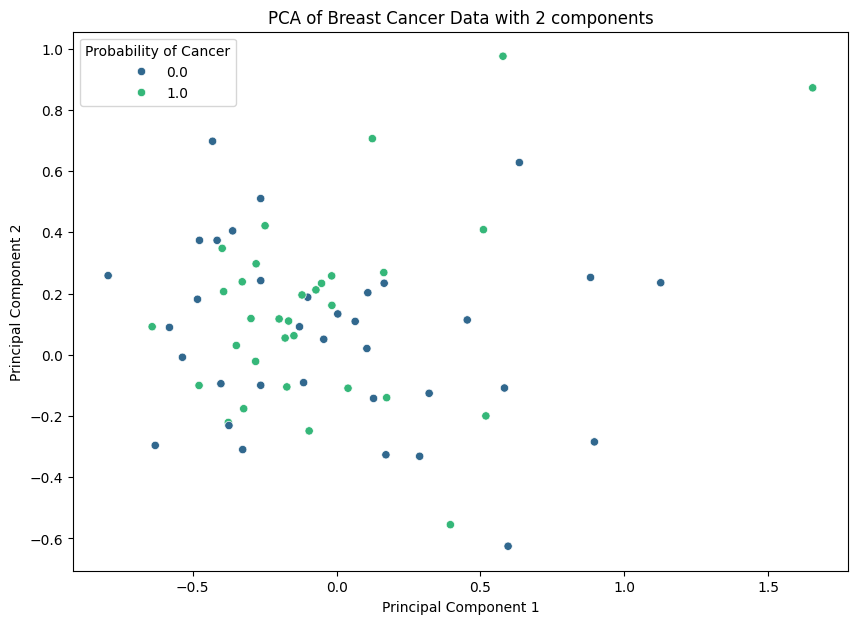

In [128]:
#generate PCA for the data with 2 components
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_test_pca, columns=['PC1', 'PC2'])
pca_df['target'] = cancer_df['target']

# Plot the PCA results
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='target', data=pca_df, palette='viridis')
plt.title('PCA of Breast Cancer Data with 2 components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Probability of Cancer')
plt.savefig('images/PCA_two_features.jpeg')
plt.show()

In [129]:
# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)

Explained Variance Ratio: [0.45416736 0.17682384]


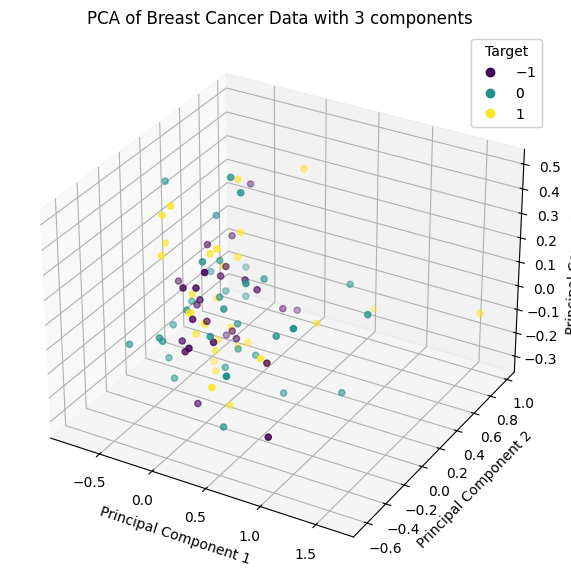

In [130]:
pca2 = PCA(n_components=3)
X_train_pca2 = pca2.fit_transform(X_train)
X_test_pca2 = pca2.transform(X_test)

# Create a DataFrame for the PCA results
pca_df2 = pd.DataFrame(data=X_test_pca2, columns=['PC1', 'PC2','PC3'])
pca_df2['target'] = cancer_df['target']

# Plot the PCA result
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(pca_df2['PC1'], pca_df2['PC2'], pca_df2['PC3'], c=pca_df2['target'].astype('category').cat.codes, cmap='viridis')

# Add labels and title
ax.set_title('PCA of Breast Cancer Data with 3 components')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Target")
ax.add_artist(legend1)
plt.savefig('images/pca_components3.jpeg')
plt.show()

##Save data into CSV file for further processing in Evaluation notebook

In [131]:
#save data into CSV file to use in another notebook to evaluate ML models
cancer_normalized_df.to_csv('data/cancer_normalized_df.csv', index=False)